# 8.1 序列模型

流程：
- 先理解序列建模的统计视角（自回归、马尔可夫、因果性）
- 再用一个带噪声的正弦序列做时序预测实验
- 对比单步预测与多步预测，观察误差累积

In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

## 1. 序列建模的基本问题

目标：给定历史观测 $x_1, x_2, ..., x_{t-1}$，预测当前值 $x_t$。

常见建模思路：
- 自回归：$x_t im P(x_t|x_{t-1}, ..., x_{t-\tau})$，只看最近 $\tau$ 个时间步
- 隐变量自回归：用状态 $h_t=g(h_{t-1},x_{t-1})$ 压缩历史，再预测 $x_t$
- 马尔可夫假设：未来在给定有限历史后与更久远过去近似独立

关键点：时序数据通常有方向性（因果性），训练和评估要尊重时间顺序。

## 2. 生成实验数据

使用带噪声的正弦波构造一个可控的一维时间序列：
- 总长度 $T=1000$
- 信号为 $\sin(0.01t)$
- 叠加均值为 0、标准差为 0.2 的高斯噪声

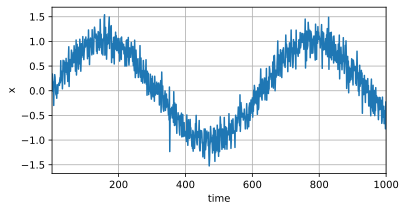

In [2]:
T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))
d2l.plot(time, [x], 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

## 3. 构造特征-标签

设时间窗口（滞后阶数）$\tau=4$，把序列转成监督学习样本：
- 特征：$[x_{t-4}, x_{t-3}, x_{t-2}, x_{t-1}]$
- 标签：$x_t$

只取前 600 个样本训练，其余用于观察泛化与外推效果。

In [3]:
tau = 4
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = d2l.load_array((features[:n_train], labels[:n_train]),
                            batch_size, is_train=True)

## 4. 训练一个简单 MLP 作为自回归预测器

In [4]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net = nn.Sequential(nn.Linear(4, 10),
                        nn.ReLU(),
                        nn.Linear(10, 1))
    net.apply(init_weights)
    return net

def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X_batch, y_batch in train_iter:
            trainer.zero_grad()
            l = loss(net(X_batch), y_batch)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch + 1}, loss: {d2l.evaluate_loss(net, train_iter, loss):f}')

net = get_net()
loss = nn.MSELoss(reduction='none')
train(net, train_iter, loss, 5, 0.01)

epoch 1, loss: 0.053511
epoch 2, loss: 0.050673
epoch 3, loss: 0.048773
epoch 4, loss: 0.048989
epoch 5, loss: 0.047590


## 5. 单步预测 vs 多步预测

单步预测（1-step）：每次都使用真实历史值作为输入，通常效果较好。

多步预测（k-step）：从某个时刻开始，后续输入中会混入模型自己的预测值，
误差会在递推中不断累积，因此预测容易漂移或塌缩。

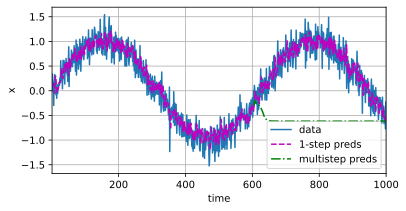

In [5]:
onestep_preds = net(features)

multistep_preds = torch.zeros(T)
multistep_preds[: n_train + tau] = x[: n_train + tau]
for i in range(n_train + tau, T):
    multistep_preds[i] = net(multistep_preds[i - tau:i].reshape((1, -1)))

d2l.plot([time, time[tau:], time[n_train + tau:]],
         [x.detach().numpy(),
          onestep_preds.detach().numpy(),
          multistep_preds[n_train + tau:].detach().numpy()],
         'time', 'x', legend=['data', '1-step preds', 'multistep preds'],
         xlim=[1, 1000], figsize=(6, 3))

## 6. 不同预测步长的对比（1/4/16/64步）

为了直观看误差如何随步长增长，按课件方式构造滚动预测矩阵并画图。

结论通常是：
- 短期（如 1、4 步）仍可用
- 中长期（如 16、64 步）误差明显放大，预测质量显著下降

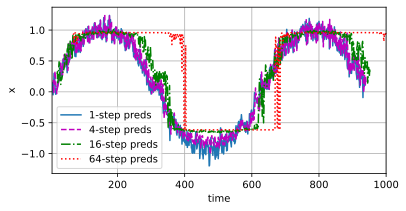

In [6]:
max_steps = 64
features_k = torch.zeros((T - tau - max_steps + 1, tau + max_steps))
for i in range(tau):
    features_k[:, i] = x[i: i + T - tau - max_steps + 1]
for i in range(tau, tau + max_steps):
    features_k[:, i] = net(features_k[:, i - tau:i]).reshape(-1)

steps = (1, 4, 16, 64)
d2l.plot([time[tau + i - 1: T - max_steps + i] for i in steps],
         [features_k[:, tau + i - 1].detach().numpy() for i in steps],
         'time', 'x', legend=[f'{i}-step preds' for i in steps],
         xlim=[5, 1000], figsize=(6, 3))

## 小结

- 序列预测本质是估计条件分布 $P(x_t|x_{<t})$，时间顺序不能打乱。
- 自回归模型通过有限窗口近似历史，计算简单、实现直接。
- 单步预测通常优于多步预测，多步预测的核心难点是误差累积。
- 这是后续 RNN/GRU/LSTM 等模型要解决的重要动机之一。